In [1]:
import os

import pandas as pd
import numpy as np

from sklearn.metrics import cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

from paths import *
from analysis_utils import get_aggregated_dataframe

plot_output_folder = f"test_results_plots"
os.makedirs(plot_output_folder, exist_ok=True)

df_results_aggregated, df_case, df_case_merged = get_aggregated_dataframe(experiment_folders_test)
df_case_merged.head()

,case_idxs,human_preds,human_confs,llm_preds,llm_reasoning,is_correct_multi,is_correct_maj,humans_agree,human_maj,idx_new,...,User Prompt,model_name,num_params,config_path,temperature,Text/Decision,Year,link,archive_link,CASE OUTCOME
0,-1.0,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('HIGH', '-'), ('HIGH', '-'), (None, None))",NO CREDIBILITY ASSESSMENT,### Step 1: Clarify Understanding of the Task ...,True,True,True,NO CREDIBILITY ASSESSMENT,0,...,UP4,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet omgjorde i april 2023 Udlændingestyrels...,2023,https://fln.dk/praksis/2023/maj/29b-graek20233/,https://web.archive.org/web/20260228212808/htt...,rejection_reversed
1,-1.0,"('NEGATIVE CREDIBILITY ASSESSMENT', 'NEGATIVE ...","(('HIGH', 'HIGH'), ('HIGH', 'HIGH'), (None, No...",NEGATIVE CREDIBILITY ASSESSMENT,### Step 1: Clarify Understanding of the Task ...,True,True,True,NEGATIVE CREDIBILITY ASSESSMENT,1,...,UP4,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet stadfæstede i maj 2025 Udlændingestyrel...,2025,https://fln.dk/praksis/2025/maj/arme20255/,https://web.archive.org/web/20260303200243/htt...,rejection_upheld
2,-1.0,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('HIGH', '-'), ('HIGH', '-'), (None, None))",NO CREDIBILITY ASSESSMENT,### Step 1: Clarify Understanding of the Task ...,True,True,True,NO CREDIBILITY ASSESSMENT,2,...,UP4,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet stadfæstede i juli 2025 Udlændingestyre...,2025,https://fln.dk/praksis/2025/juni/dub-tysk202518/,https://web.archive.org/web/20260303200553/htt...,rejection_upheld
3,-1.0,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('MEDIUM', '-'), ('HIGH', '-'), (None, None))",NO CREDIBILITY ASSESSMENT,### Step 1: Clarify Understanding of the Task ...,True,True,True,NO CREDIBILITY ASSESSMENT,3,...,UP4,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet stadfæstede i juli 2025 Udlændingestyre...,2025,https://fln.dk/praksis/2025/juli/dub-tysk202519/,https://web.archive.org/web/20260303200703/htt...,rejection_upheld
4,-1.0,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('HIGH', '-'), ('HIGH', '-'), (None, None))",NO CREDIBILITY ASSESSMENT,### Step 1: Clarify Understanding of the Task ...,True,True,True,NO CREDIBILITY ASSESSMENT,4,...,UP4,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet stadfæstede i maj og 2025 Udlændingesty...,2025,https://fln.dk/praksis/2025/maj/29b-tysk20253/,https://web.archive.org/web/20260303211724/htt...,rejection_upheld


Number of cases where mistralai/Mistral-Small-3.2-24B-Instruct-2506 with SP3+UP1-FS and mistralai/Mistral-Small-3.2-24B-Instruct-2506 with SP4+UP1 agree: 190
Number of cases where mistralai/Mistral-Small-3.2-24B-Instruct-2506 with SP3+UP1-FS and mistralai/Mistral-Small-3.2-24B-Instruct-2506 with SP4+UP1 disagree: 10
--> Cohen's kappa between mistralai/Mistral-Small-3.2-24B-Instruct-2506 with SP3+UP1-FS and mistralai/Mistral-Small-3.2-24B-Instruct-2506 with SP4+UP1: 0.9223
Number of cases where microsoft/phi-4 with SP4+UP2 and microsoft/phi-4 with SP4+UP4 agree: 189
Number of cases where microsoft/phi-4 with SP4+UP2 and microsoft/phi-4 with SP4+UP4 disagree: 11
--> Cohen's kappa between microsoft/phi-4 with SP4+UP2 and microsoft/phi-4 with SP4+UP4: 0.9133
Cohen's kappa between human annotator 1 and human annotator 2: 0.967016
Cohen's kappa between human annotator 1 and human majority: 0.983525
Cohen's kappa between human annotator 2 and human majority: 0.983464
All models and prompts of

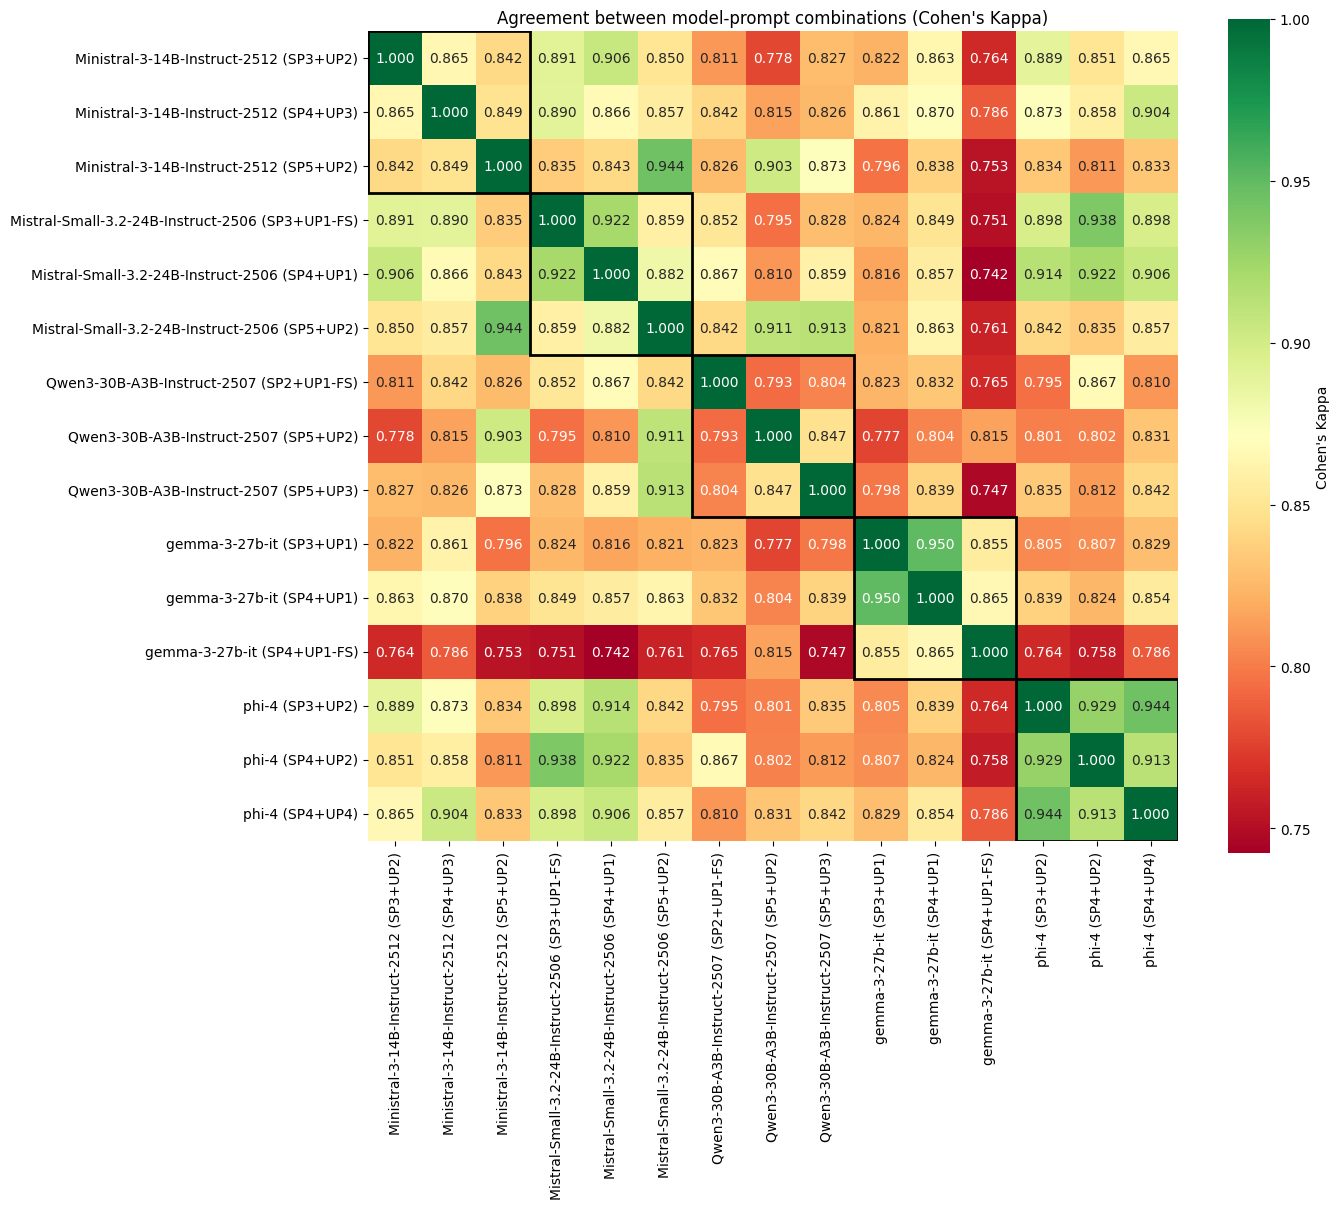

In [2]:
combos = [
    (["mistralai/Mistral-Small-3.2-24B-Instruct-2506", "SP3", "UP1-FS"],["mistralai/Mistral-Small-3.2-24B-Instruct-2506", "SP4", "UP1"]),
    (["microsoft/phi-4", "SP4", "UP2"],["microsoft/phi-4", "SP4", "UP4"])
]
def agreement_between_pair(pair1, pair2, df_case=df_case, print_res=True):

        model1, sp1, up1 = pair1
        model2, sp2, up2 = pair2

        # models of interest: (phi-4 with SP4+UP2, and phi-4 with SP4+UP4)
        cases_of_interest_1 = df_case[(df_case["model_name"] == model1) & (df_case["System Prompt"] == sp1) & (df_case["User Prompt"] == up1)]["llm_preds"]
        cases_of_interest_2 = df_case[(df_case["model_name"] == model2) & (df_case["System Prompt"] == sp2) & (df_case["User Prompt"] == up2)]["llm_preds"]

        # compute cohen's kappa between the two sets of predictions
        kappa = cohen_kappa_score(cases_of_interest_1, cases_of_interest_2)
        # number of cases where the two sets of predictions agree
        num_agree = (cases_of_interest_1.values == cases_of_interest_2.values).sum()
        num_disagree = (cases_of_interest_1.values != cases_of_interest_2.values).sum()

        if print_res:
            print(f"Number of cases where {model1} with {sp1}+{up1} and {model2} with {sp2}+{up2} agree: {num_agree}")
            print(f"Number of cases where {model1} with {sp1}+{up1} and {model2} with {sp2}+{up2} disagree: {num_disagree}")
            print(f"--> Cohen's kappa between {model1} with {sp1}+{up1} and {model2} with {sp2}+{up2}: {kappa:.4f}")

        return kappa

for pair1, pair2 in combos:
    agreement_between_pair(pair1, pair2, df_case=df_case)

df_case_per_annotator = df_case.groupby("case_idxs")[["human_preds","human_maj"]].first().reset_index()
df_case_h1 = df_case_per_annotator["human_preds"].apply(lambda x: eval(x)[0])
df_case_h2 = df_case_per_annotator["human_preds"].apply(lambda x: eval(x)[1])
# cohen between h1 and h2
kappa_h1_h2 = cohen_kappa_score(df_case_h1, df_case_h2)
print(f"Cohen's kappa between human annotator 1 and human annotator 2: {kappa_h1_h2:.6f}")

# compute cohen's kappa between h1 and maj
kappa_h1_maj = cohen_kappa_score(df_case_h1, df_case_per_annotator["human_maj"])
print(f"Cohen's kappa between human annotator 1 and human majority: {kappa_h1_maj:.6f}")
kappa_h2_maj = cohen_kappa_score(df_case_h2, df_case_per_annotator["human_maj"])
print(f"Cohen's kappa between human annotator 2 and human majority: {kappa_h2_maj:.6f}")


all_models = []
for model, promps in combos_of_interest.items():
    for prompt in promps:
        all_models.append((model, prompt[0], prompt[1]))
print("All models and prompts of interest:", all_models)
assert len(all_models) == 15 and len(set(all_models)) == 15, f"Expected 15 model-prompt combinations, but got {len(all_models)}. Check if all expected combinations were generated correctly."

all_combos = []
# for every list in all_models, create a combo with every other list in all_models
for i in range(len(all_models)):
    for j in range(len(all_models)):
        all_combos.append((all_models[i], all_models[j]))
assert len(all_combos) == 15 * 15, f"Expected 225 total combinations, but got {len(all_combos)}. Check if all combinations were generated correctly."

list_of_agreement_dicts = []
done_pairs = set()
for pair1, pair2 in all_combos:
    model_name1, sp1, up1 = pair1
    model_name2, sp2, up2 = pair2
    model_name1_short = model_name1.split("/")[-1]
    model_name2_short = model_name2.split("/")[-1]
    pair1_str = f"{model_name1_short} ({sp1}+{up1})"
    pair2_str = f"{model_name2_short} ({sp2}+{up2})"
    done_pairs.add((pair1_str, pair2_str))
    
    kappa = agreement_between_pair(pair1, pair2, df_case=df_case, print_res=False)
    list_of_agreement_dicts.append({
        "pair1": pair1_str,
        "pair2": pair2_str,
        "kappa": kappa
    })
df_agreements = pd.DataFrame(list_of_agreement_dicts).sort_values(by="kappa", ascending=False)
df_agreements = df_agreements.sort_values(by=["pair1", "pair2"]).reset_index() # don't truncate the output of this dataframe for any column
print(df_agreements.to_string())

# create a confusion matrix from df_agreements, where the rows and columns are the models (with prompts) and the values are the kappa values. This will be a symmetric matrix with 1s on the diagonal.
assert df_agreements["pair2"].nunique() == 15, f"Expected 15 unique pairs in pair2, but got {df_agreements['pair2'].unique()}. Check if all expected pairs were computed correctly."
assert df_agreements["pair1"].nunique() == 15, f"Expected 15 unique pairs in pair1, but got {len(df_agreements['pair1'].unique())}. Check if all expected pairs were computed correctly."
confusion_matrix = pd.DataFrame(index=sorted(df_agreements["pair1"].unique()), columns=sorted(df_agreements["pair1"].unique()))

print(confusion_matrix.columns, confusion_matrix.index)

for _, row in df_agreements.iterrows():
    pair1 = row["pair1"]
    pair2 = row["pair2"]
    kappa = row["kappa"]
    confusion_matrix.loc[str(pair1), str(pair2)] = kappa
    confusion_matrix.loc[str(pair2), str(pair1)] = kappa
confusion_matrix.fillna(1.0, inplace=True) # fill the diagonal and any missing values with 1.0
print("Confusion matrix of Cohen's kappa values between model-prompt combinations:")
print(confusion_matrix.to_string())



plt.figure(figsize=(14,12))

sns.heatmap(confusion_matrix.astype(float), annot=True, cmap="RdYlGn", cbar_kws={'label': "Cohen's Kappa"}, fmt=".3f")

for i, j in [(0,0),(3,3),(6,6),(9,9),(12,12)]:
    plt.gca().add_patch(plt.Rectangle((j, i), 3, 3, fill=False, edgecolor='black', lw=2))

plt.title("Agreement between model-prompt combinations (Cohen's Kappa)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig(f"{plot_output_folder}/model_agreement_heatmap.pdf", dpi=300)
plt.savefig(f"{plot_output_folder}/model_agreement_heatmap.png", dpi=300)
plt.show()


In [3]:
CORRECTNESS_MEASURE = "is_correct_maj"

columns_of_interest = ["case_idxs","idx_new","human_maj","human_preds","human_confs","humans_agree", "CASE OUTCOME","Text/Decision", "Year"]

custom_agg_function = lambda x: pd.Series.mode(x)[0] if len(pd.Series.mode(x)) > 0 else np.nan

df_case_accuracy = df_case_merged.groupby(columns_of_interest)[CORRECTNESS_MEASURE].mean().reset_index()
df_case_nunique = df_case_merged.groupby(columns_of_interest)["llm_preds"].nunique().reset_index()
df_case_majvote = df_case_merged.groupby(columns_of_interest)["llm_preds"].agg(custom_agg_function).reset_index()
df_case_nmajvote = df_case_merged.groupby(columns_of_interest)["llm_preds"].apply(lambda x: x.value_counts().iloc[0]).reset_index()

# combine the 3 dataframes into one dataframe
df_case_agg = df_case_accuracy.merge(df_case_nunique, on=columns_of_interest)
df_case_agg = df_case_agg.merge(df_case_majvote, on=columns_of_interest)
df_case_agg = df_case_agg.merge(df_case_nmajvote, on=columns_of_interest)
df_case_agg.rename(columns={"llm_preds_x": "llm_preds_nunique", "llm_preds_y": "llm_preds_majvote", "llm_preds": "llm_preds_majvote_n"}, inplace=True)
print("\nAccuracy per case:")

assert len(df_case_agg) == 200, f"Expected 200 unique cases, but got {len(df_case_agg)}. Check the grouping and merging steps for correctness."

assert len(df_case_agg[df_case_agg["humans_agree"] == False]) == 4

def extract_single_conf(conf_str):
    conf_list = eval(conf_str)
    final_conf_per_human = []
    for conf in conf_list:
        if conf[0] is not None and conf[1] is not None:
            final_conf_per_human.append(min(conf, key=lambda c: {"HIGH": 3, "MEDIUM": 2, "LOW": 1, "-": 100}.get(c)))
    final_conf = min(final_conf_per_human, key=lambda c: {"HIGH": 3, "MEDIUM": 2, "LOW": 1}.get(c))
    #print(f"Final conf: {final_conf}")
    return final_conf

def extract_mistake_type(row):
    if (row["human_maj"] == "POSITIVE CREDIBILITY ASSESSMENT") and (row["llm_preds_majvote"] == "NEGATIVE CREDIBILITY ASSESSMENT"):
        return "Predicted NEG, correct was POS"
    elif (row["human_maj"] == "POSITIVE CREDIBILITY ASSESSMENT") and (row["llm_preds_majvote"] == "NO CREDIBILITY ASSESSMENT"):
        return "Predicted NO ASSESSMENT, correct was POS"
    elif (row["human_maj"] == "NEGATIVE CREDIBILITY ASSESSMENT") and (row["llm_preds_majvote"] == "POSITIVE CREDIBILITY ASSESSMENT"):
        return "Predicted POS, correct was NEG"
    elif (row["human_maj"] == "NEGATIVE CREDIBILITY ASSESSMENT") and (row["llm_preds_majvote"] == "NO CREDIBILITY ASSESSMENT"):
        return "Predicted NO ASSESSMENT, correct was NEG"
    elif (row["human_maj"] == "NO CREDIBILITY ASSESSMENT") and (row["llm_preds_majvote"] == "POSITIVE CREDIBILITY ASSESSMENT"):
        return "Predicted POS, correct was NO ASSESSMENT"
    elif (row["human_maj"] == "NO CREDIBILITY ASSESSMENT") and (row["llm_preds_majvote"] == "NEGATIVE CREDIBILITY ASSESSMENT"):
        return "Predicted NEG, correct was NO ASSESSMENT"
            
df_case_agg["human_conf_min"] = df_case_agg["human_confs"].apply(extract_single_conf)
df_case_agg["num_characters"] = df_case_agg["Text/Decision"].apply(lambda x: float(len(x)))
df_case_agg["mistake_type_maj"] = df_case_agg.apply(lambda row: extract_mistake_type(row), axis=1)
df_case_agg["opposite_outcome"] = df_case_agg.apply(
    lambda row: (row["human_maj"] == "POSITIVE CREDIBILITY ASSESSMENT" and row["CASE OUTCOME"] == "rejection_upheld") or (row["human_maj"] == "NEGATIVE CREDIBILITY ASSESSMENT" and row["CASE OUTCOME"] == "rejection_reversed"), axis=1)
df_case_agg.sort_values(by=["is_correct_maj"], ascending=True).head()
df_case_agg.sort_values(by=["is_correct_maj"], ascending=True)[["case_idxs", "is_correct_maj", "llm_preds_majvote", "human_maj","human_preds","human_confs","humans_agree", "CASE OUTCOME","Text/Decision", "Year"]].to_csv("case_level_analysis.csv", index=False)


Accuracy per case:


Number of cases with perfect LLM agreement with human majority vote: 144 out of 200 (72.00%)
Number of cases with majority of LLM annotators correct: 190 out of 200 (95.00%)


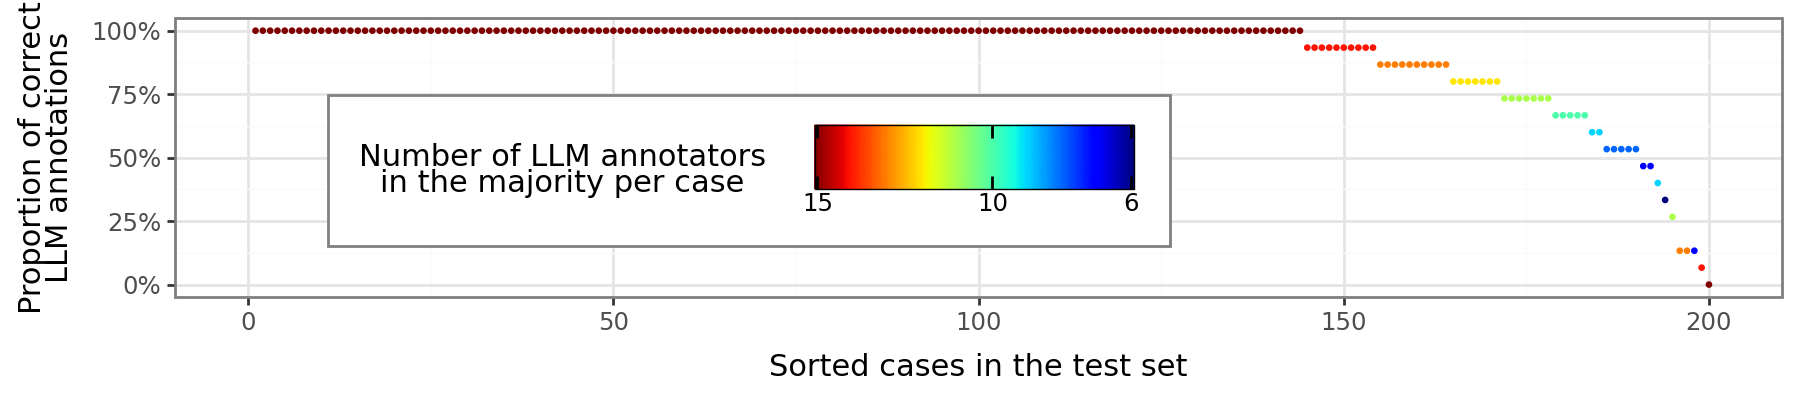

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 9 x 2 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: test_results_plots/test_casewise_accuracy_agreement.pdf
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 9 x 2 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: test_results_plots/test_casewise_accuracy_agreement.png


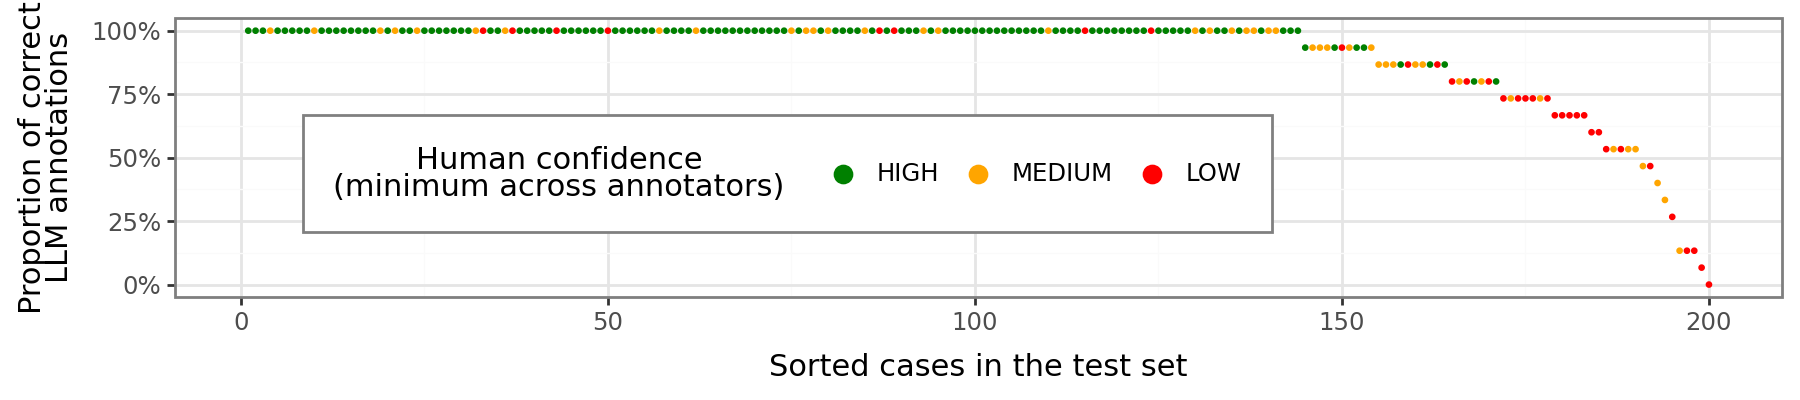

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 9 x 2 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: test_results_plots/test_casewise_accuracy_human_conf.pdf
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 9 x 2 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: test_results_plots/test_casewise_accuracy_human_conf.png


In [4]:
# create a plot with case idx on x-axis and accuracy on y-axis, with different lines for different human_preds
import plotnine as p9
import numpy as np


df_case_agg_sorted = df_case_agg.sort_values(by=[CORRECTNESS_MEASURE], ascending=False)
df_case_agg_sorted["idx_new_sorted"] = np.array(range(1,len(df_case_agg_sorted)+1))

assert len(df_case_agg) == 200
# calculate number of cases with CORRECTNESS_MEASURE == 1
num_allcorrect = (df_case_agg_sorted[CORRECTNESS_MEASURE] == 1).sum()
print(f"Number of cases with perfect LLM agreement with human majority vote: {num_allcorrect} out of 200 ({num_allcorrect/200:.2%})")
num_majcorrect = (df_case_agg_sorted[CORRECTNESS_MEASURE] >= 0.5).sum()
print(f"Number of cases with majority of LLM annotators correct: {num_majcorrect} out of 200 ({num_majcorrect/200:.2%})")

formatting = (
    p9.theme_bw() +
    p9.theme(figure_size=(9, 2)) +
    p9.theme(legend_position=(0.2,0.4), legend_box_margin=10,
             legend_direction="horizontal", legend_frame=p9.element_rect(color="black", size=0.5, fill="gray"), legend_ticks=p9.element_line(color="black"),
             legend_background=p9.element_rect(color="gray", size=1, fill="white"))

)

plt = (p9.ggplot(df_case_agg_sorted, p9.aes(x="idx_new_sorted", y=CORRECTNESS_MEASURE, color="llm_preds_majvote_n")) + 
    p9.geom_point(size=0.35) + 
    p9.scale_color_cmap(cmap_name="jet", breaks=[15,10,6]) +
    p9.scale_y_continuous(labels=lambda l: ["{:.0f}%".format(x*100) for x in l]) +
    p9.xlim(0, 200) +
    p9.guides(color=p9.guide_colorbar(reverse=True)) +
    formatting +
    p9.labs(x="Sorted cases in the test set", y="Proportion of correct\nLLM annotations", color="Number of LLM annotators\nin the majority per case")
)
plt.show()
plt.save(f"test_results_plots/test_casewise_accuracy_agreement.pdf")
plt.save(f"test_results_plots/test_casewise_accuracy_agreement.png")

plt = (p9.ggplot(df_case_agg_sorted, p9.aes(x="idx_new_sorted", y=CORRECTNESS_MEASURE, color="human_conf_min")) + 
    p9.geom_point(size=0.35) + 
    p9.scale_color_manual(values={"HIGH": "green", "MEDIUM": "orange", "LOW": "red"}, breaks=["HIGH", "MEDIUM", "LOW"]) +
    p9.scale_y_continuous(labels=lambda l: ["{:.0f}%".format(x*100) for x in l]) +
    formatting +
    p9.guides(color=p9.guide_legend(override_aes={'size': 3})) +
    p9.labs(x="Sorted cases in the test set", y="Proportion of correct\nLLM annotations", color="Human confidence\n(minimum across annotators)")
)
plt.show()
plt.save(f"{plot_output_folder}/test_casewise_accuracy_human_conf.pdf")
plt.save(f"{plot_output_folder}/test_casewise_accuracy_human_conf.png")


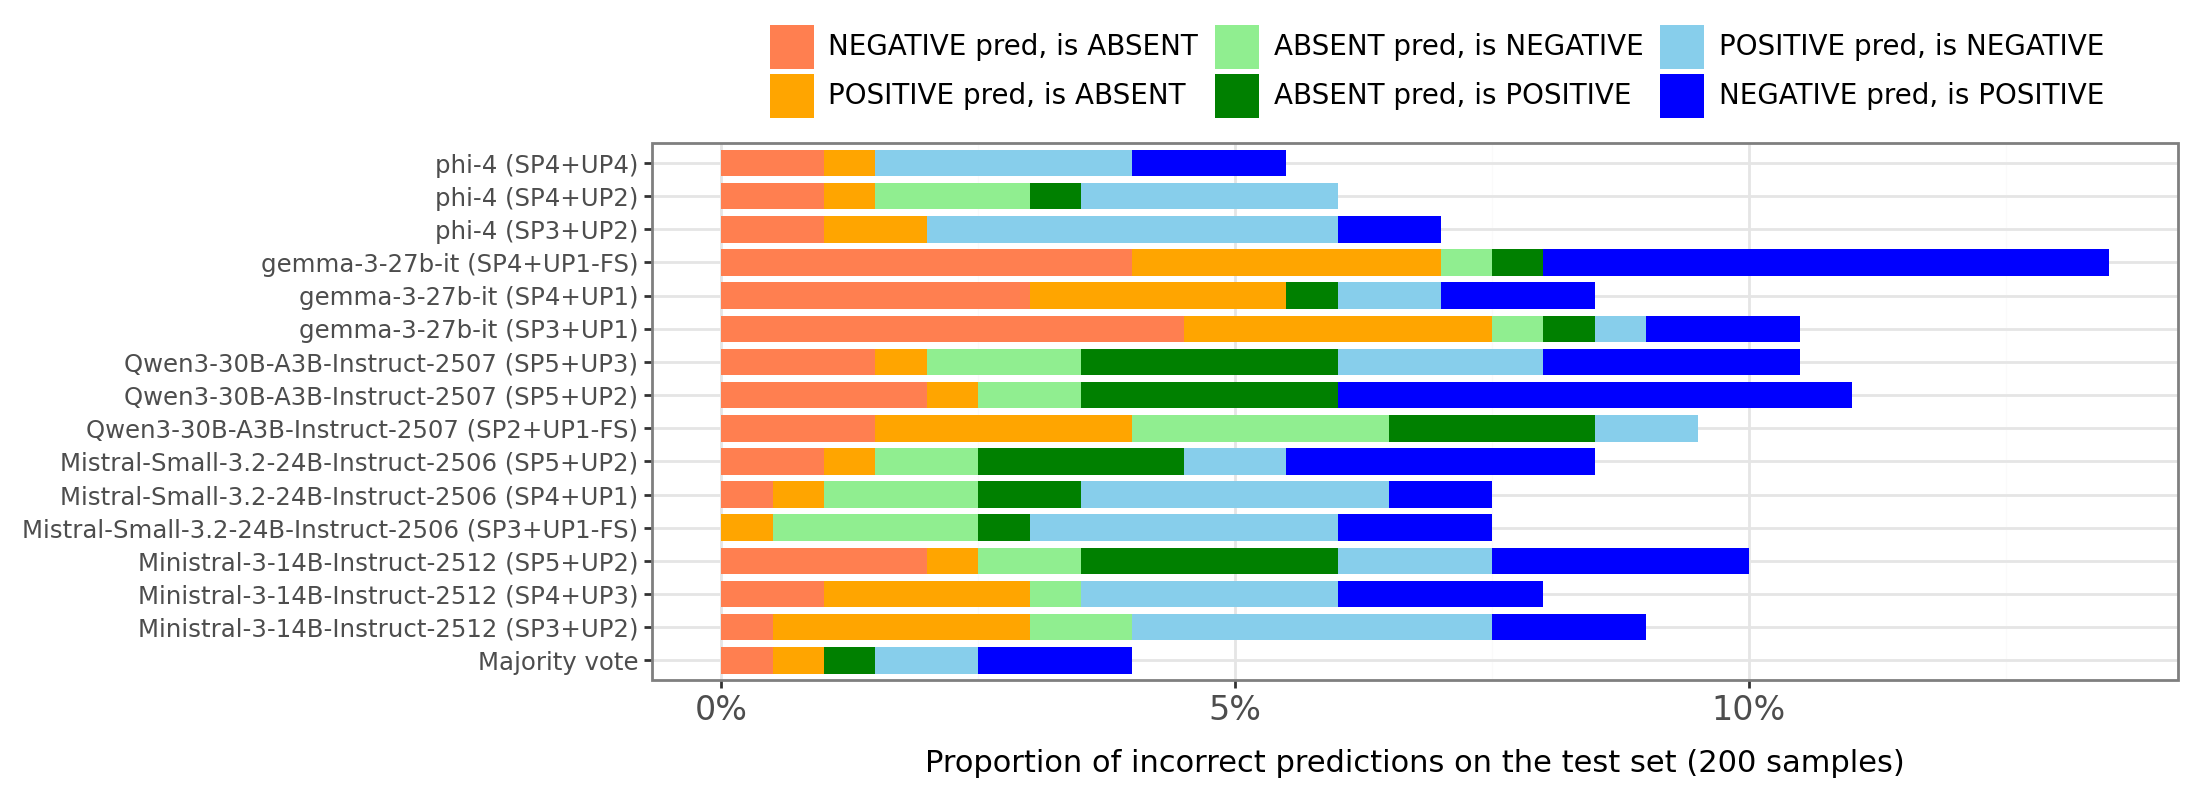

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 11 x 4 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: test_results_plots/mistake_type_raw_by_model_prompt.png
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 11 x 4 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: test_results_plots/mistake_type_raw_by_model_prompt.pdf


In [5]:
df_case_merged_2 = df_case_merged.copy()

def extract_mistake_binary(pred, gt):
    if (gt == "POSITIVE CREDIBILITY ASSESSMENT") and (pred == "NEGATIVE CREDIBILITY ASSESSMENT"):
        return "Incorrect about SENTIMENT"
    elif (gt == "NEGATIVE CREDIBILITY ASSESSMENT") and (pred == "POSITIVE CREDIBILITY ASSESSMENT"):
        return "Incorrect about SENTIMENT"
    elif (gt in ["POSITIVE CREDIBILITY ASSESSMENT", "NEGATIVE CREDIBILITY ASSESSMENT"]) and (pred == "NO CREDIBILITY ASSESSMENT"):
        return "Incorrect about PRESENCE"
    elif (gt == "NO CREDIBILITY ASSESSMENT") and (pred in ["POSITIVE CREDIBILITY ASSESSMENT", "NEGATIVE CREDIBILITY ASSESSMENT"]):
        return "Incorrect about PRESENCE"
    else:
        return "Correct"
    
def extract_mistake_type(pred, gt):
       if (gt == "POSITIVE CREDIBILITY ASSESSMENT") and (pred == "NEGATIVE CREDIBILITY ASSESSMENT"):
              return "NEGATIVE pred, is POSITIVE"
       elif (gt == "NEGATIVE CREDIBILITY ASSESSMENT") and (pred == "POSITIVE CREDIBILITY ASSESSMENT"):
              return "POSITIVE pred, is NEGATIVE"
       elif (gt == "POSITIVE CREDIBILITY ASSESSMENT") and (pred == "NO CREDIBILITY ASSESSMENT"):
              return "ABSENT pred, is POSITIVE"
       elif (gt == "NEGATIVE CREDIBILITY ASSESSMENT") and (pred == "NO CREDIBILITY ASSESSMENT"):
              return "ABSENT pred, is NEGATIVE"
       elif (gt == "NO CREDIBILITY ASSESSMENT") and (pred == "POSITIVE CREDIBILITY ASSESSMENT"):
              return "POSITIVE pred, is ABSENT"
       elif (gt == "NO CREDIBILITY ASSESSMENT") and (pred == "NEGATIVE CREDIBILITY ASSESSMENT"):
              return "NEGATIVE pred, is ABSENT"
       else:
              return "Correct"

def extract_mistake_outcome(pred, gt, outcome):
    assert outcome in ["remanded", "rejection_reversed", "rejection_upheld"], f"Unexpected outcome value: {outcome}. Expected one of ['remanded', 'rejection_reversed', 'rejection_upheld']."
    if gt != pred:
        if (pred == "NO CREDIBILITY ASSESSMENT" and outcome == "remanded") or (pred == "POSITIVE CREDIBILITY ASSESSMENT" and outcome == "rejection_reversed") or (pred == "NEGATIVE CREDIBILITY ASSESSMENT" and outcome == "rejection_upheld"):
            return "Incorrect, aligning with outcome"
        else:
            return "Incorrect, not aligning with outcome"
    else:
        return "Correct"

colors = {
       "NEGATIVE pred, is POSITIVE": "blue",
       "POSITIVE pred, is NEGATIVE": "skyblue",
       "ABSENT pred, is POSITIVE": "green",
       "ABSENT pred, is NEGATIVE": "lightgreen",
       "POSITIVE pred, is ABSENT": "orange",
       "NEGATIVE pred, is ABSENT": "coral"
}


# mistake types is either confusing SENTIMENT (pred NEGATIVE CREDIBILITY ASSESSMENT, was POSITIVE CREDIBILITY ASSESSMEN or pred POSITIVE CREDIBILITY ASSESSMENT, was NEGATIVE CREDIBILITY ASSESSMENT), or confusing ASSESSMENT with NO ASSESSMENT (pred NO CREDIBILITY ASSESSMENT, was POSITIVE or NEGATIVE CREDIBILITY ASSESSMENT, or pred POSITIVE or NEGATIVE CREDIBILITY ASSESSMENT, was NO ASSESSMENT)
df_case_merged_2["mistake_type_binary"] = df_case_merged_2.apply(lambda row: extract_mistake_binary(row["llm_preds"], row["human_maj"]), axis=1)
df_case_merged_2["mistake_type_raw"] = df_case_merged_2.apply(lambda row: extract_mistake_type(row["llm_preds"], row["human_maj"]), axis=1)

df_case_merged_2["model prompt"] = df_case_merged_2.apply(lambda row: f"{row['model_name'].split('/')[-1]} ({row['System Prompt']}+{row['User Prompt']})", axis=1)

# add predictions by the LLM majority vote per case to df_case_merged
df_case_merged_2 = pd.merge(df_case_merged_2, df_case_agg[["idx_new","llm_preds_majvote"]], on="idx_new", how="left")

# create additional rows for the LLM majority vote per case, with the same mistake type as the individual predictions (so if the LLM majority vote is different from the human majority vote, then the mistake type is the same as the individual predictions, and if the LLM majority vote is the same as the human majority vote, then the mistake type is "Correct")
df_case_merged_2["mistake_type_outcome"] = df_case_merged_2.apply(lambda row: extract_mistake_outcome(row["llm_preds"], row["human_maj"], row["CASE OUTCOME"]), axis=1)


df_case_majvote = df_case_agg_sorted[["idx_new","llm_preds_majvote"]].copy()
df_case_majvote["model prompt"] = "Majority vote"
df_case_majvote["mistake_type_binary"] = df_case_majvote.apply(lambda row: extract_mistake_binary(row["llm_preds_majvote"], df_case_agg[df_case_agg["idx_new"] == row["idx_new"]]["human_maj"].values[0]), axis=1)

# add the outcome to df_case_majvote
df_case_majvote = pd.merge(df_case_majvote, df_case_agg[["idx_new","CASE OUTCOME"]], on="idx_new", how="left")

df_case_majvote["mistake_type_raw"] = df_case_majvote.apply(lambda row: extract_mistake_type(row["llm_preds_majvote"], df_case_agg[df_case_agg["idx_new"] == row["idx_new"]]["human_maj"].values[0]), axis=1)
df_case_majvote["mistake_type_outcome"] = df_case_majvote.apply(lambda row: extract_mistake_outcome(row["llm_preds_majvote"], df_case_agg[df_case_agg["idx_new"] == row["idx_new"]]["human_maj"].values[0], row["CASE OUTCOME"]), axis=1)
df_case_merged_2 = pd.concat([df_case_merged_2, df_case_majvote], ignore_index=True)
assert len(df_case_majvote) == 200, f"Expected 200 rows in df_case_majvote, but got {len(df_case_majvote)}. Check the creation of df_case_majvote for correctness."
#assert len(df_case_merged_2) == len(df_case_merged_2) + len(df_case_agg), f"Expected {len(df_case_merged) + len(df_case_agg)} rows in df_case_merged_2, but got {len#"(df_case_merged_2)}. Check the concatenation step for correctness."

df_case_merged_2 = df_case_merged_2[df_case_merged_2["mistake_type_binary"] != "Correct"]
# plot a stacked bar chart of mistake types across cases x predictions

df_case_merged_2["mistake_type_raw"] = pd.Categorical(df_case_merged_2["mistake_type_raw"], categories=colors.keys(), ordered=True)

from mizani.formatters import percent_format
plt = (p9.ggplot(df_case_merged_2, p9.aes(x="model prompt", fill="mistake_type_raw")) + 
       p9.geom_bar(width=0.8) +
       p9.coord_flip() +
       p9.scale_fill_manual(guide=p9.guide_legend(nrow=2, ), values=colors, breaks=list(colors.keys())) +
       p9.scale_y_continuous(labels=lambda l: ["%d%%" % (v/200 * 100) for v in l]) +
       p9.theme_bw() +
       p9.guides(fill=p9.guide_legend(byrow=False, reverse=True)) +
       p9.theme(legend_position="top", figure_size=(11, 4), legend_box_margin=0, legend_text=p9.element_text(size=10), axis_text_x=p9.element_text(size=12), legend_box_spacing=0.01) +
       p9.labs(x="", y="Proportion of incorrect predictions on the test set (200 samples)", fill="" )
)
plt.show()
plt.save(f"{plot_output_folder}/mistake_type_raw_by_model_prompt.png")
plt.save(f"{plot_output_folder}/mistake_type_raw_by_model_prompt.pdf")

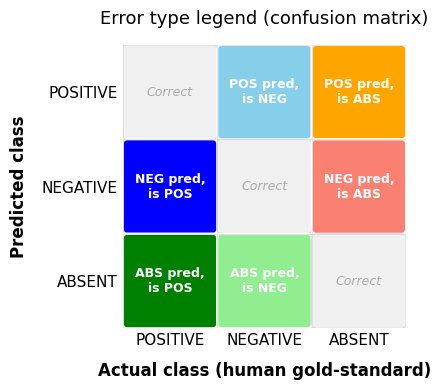

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
classes = ["POSITIVE", "NEGATIVE", "ABSENT"]

 
colors = {
    ("NEGATIVE", "POSITIVE"): "blue",   
    ("NEGATIVE", "NEGATIVE"): None,         
    ("NEGATIVE", "ABSENT"):   "salmon",   
    ("POSITIVE", "POSITIVE"): None,         
    ("POSITIVE", "NEGATIVE"): "skyblue",   
    ("POSITIVE", "ABSENT"):   "orange",   
    ("ABSENT", "POSITIVE"):   "green",   
    ("ABSENT", "NEGATIVE"):   "lightgreen",   
    ("ABSENT", "ABSENT"):     None,         
}
labels = {
    ("NEGATIVE", "POSITIVE"): "NEG pred,\nis POS",
    ("NEGATIVE", "ABSENT"):   "NEG pred,\nis ABS",
    ("POSITIVE", "NEGATIVE"): "POS pred,\nis NEG",
    ("POSITIVE", "ABSENT"):   "POS pred,\nis ABS",
    ("ABSENT", "POSITIVE"):   "ABS pred,\nis POS",
    ("ABSENT", "NEGATIVE"):   "ABS pred,\nis NEG",
}
fig, ax = plt.subplots(figsize=(5,4))
n = len(classes)
for i, pred in enumerate(classes):
    for j, actual in enumerate(classes):
        color = colors.get((pred, actual))
        if color is not None:
            rect = mpatches.FancyBboxPatch(
                (j + 0.05, n - 1 - i + 0.05), 0.9, 0.9,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="white", linewidth=1.5
            )
            ax.add_patch(rect)
            label = labels.get((pred, actual), "")
            ax.text(j + 0.5, n - 1 - i + 0.5, label,
                    ha="center", va="center", fontsize=9,
                    fontweight="bold", color="white")
        else:
            rect = mpatches.FancyBboxPatch(
                (j + 0.05, n - 1 - i + 0.05), 0.9, 0.9,
                boxstyle="round,pad=0.05",
                facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.5
            )
            ax.add_patch(rect)
            ax.text(j + 0.5, n - 1 - i + 0.5, "Correct",
                    ha="center", va="center", fontsize=9,
                    color="#aaaaaa", fontstyle="italic")
ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(classes[::-1], fontsize=11)
ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_aspect("equal")
ax.set_xlabel("Actual class (human gold-standard)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Predicted class", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Error type legend (confusion matrix)", fontsize=13, pad=15)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
for i in range(n + 1):
    ax.axhline(i, color="#dddddd", linewidth=0.5)
    ax.axvline(i, color="#dddddd", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{plot_output_folder}/error_type_legend.pdf")